# Predicting drivers of patient-level multiomic profiles

In this notebook I'll explore how to use the transcriptome and proteome of patients exhibiting methylmalonic acidemia (MMA) and network analysis to generate personalized predictions of molecular drivers.

MMA is an early-onset disorder with ~50% of cases due to biallelic loss of the MMUT enzyme. MMA can also arise from loss of a handful of other genes but many cases of MMA lack a genetic diagosis. Due to the early onset and classic presentation as an inborn error metabolism these cases still likely possess a specific dysfunctional gene or dysfunctional pathway but identifying these functions from the exome alone may be because the drivers may be non-coding or they may be present as variants of unknown significance. 

To help prioritize genetic variants, functional characterization of the transcriptome and proteome can help. Forny 2023 profiled the transcriptome and proteome of patient-derived fibroblasts from 210 MMA cases and 20 controls. In XXX% of the cases a genetic diagnosis was possible while the remaining XXX patients. Achieving a genetic diagnosis provides therapeutic guidance so improving the fidelity of recovering drivers from functional genomics would improve the treatment of patients like those profiled in the Forny study.

Here, my goal is to predict candidate drivers for each of the patients. The XXX patients with a genetic diagnosis can serve as ground truth. The remainder highlight the promise of multiomics as a diagnostic tool for rare disease.

## Research strategy

1. loading data
2. loading network
3. estimating patient-level molecular profiles
    i. Calculated personalized z-scores comparing a cases' feature abundance to the distribution of controls
    ii. Shrink the estimates using empirical Bayes
    iii. Validate that MMUT is an outlier measure for patients with MMUT mutations
4. Add each patient's molecular profile as a graph vertex attribute
5. Applied personalized pagerank with a proper null distribution to find the subgraph enriched upstream of each patient's expression changes
6. Filtered to a significantly enriched subgraph.

This approach generates a robust set of vertices for each patient but the top enrichments tend to be secondary aspects of MMA pathophysiology such as stress. These top-hits could still be used for predicting drivers but only if they were cross-listed with the exome.

Filtering out non-specific cell biology would be aided by combining diverse diseases measurements into a single metaanalysis as this would allow us to reliably flag disease-specific and disease-agnostic processes (stress, cell cycle, cytoskeleton). Since doing this is out-of-scope; here, I'll cluster each personalized subgraph to try to separate primary and secondary pathophysiology, interpret the clusters with gene overexpression analysis, and accordingly label these clusters as likely symptoms rather than causes of disease.



## Environment setup

```bash
uv venv --python 3.11
source .venv/bin/activate

# Core dependencies (Napistu-Torch which bundles Napistu)
# Granular Torch installation for MPS compatibility
uv pip install torch==2.8.0
uv pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.8.0+cpu.html
uv pip install 'napistu-torch[pyg,lightning]'
# Personal utilities package with genomics analysis functions
uv pip install "git+https://github.com/shackett/shackett-utils.git[statistics,genomics]" # stats extra for GAM and lFDR support 
# Additional dependencies
uv pip install ipykernel openpyxl
python -m ipykernel install --user --name=forny-2023
```

## Import packages and define globals


In [1]:
import logging
import os
from pathlib import Path
from types import SimpleNamespace
from typing import Dict, Optional

from anndata import AnnData
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

# napistu imports
from napistu.gcs.downloads import load_public_napistu_asset
from napistu.gcs.constants import GCS_SUBASSET_NAMES
from napistu.matching.mount import resolve_matches
from napistu.network.net_propagation import (
    melt_propagation_results,
    network_propagation_with_null,
)
from napistu.network.ng_core import NapistuGraph
from napistu.network.clustering import run_infomap
from napistu.matching.species import features_to_pathway_species
from napistu.ontologies.constants import ONTOLOGIES

# napistu-torch imports
from napistu_torch.napistu_data_store import NapistuDataStore
from napistu_torch.evaluation.manager import RemoteEvaluationManager

# shackett private package imports
from shackett_utils.applications.forny_etl import forny_etl_and_normalize
from shackett_utils.genomics import adata_regression
from shackett_utils.statistics.multi_model_fitting import (
    add_lfdr,
    control_fdr,
)
from shackett_utils.statistics.hypothesis_testing import (
    calculate_log_tstat_pvalue,
    quantile_to_pvalue,
)

# setup logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
logging.getLogger('matplotlib.font_manager').setLevel(logging.WARNING)
logging.getLogger('matplotlib.pyplot').setLevel(logging.WARNING) 

# File paths and data organization
# All input data should be placed in the SUPPLEMENTAL_DATA_DIR
# Cached results and models will be stored in CACHE_DIR

# paths
PROJECT_DIR = os.path.expanduser("~/Desktop/DATA/Forny2023")

# inputs
# network model to download from GCS and store in NAPISTU_DATA_DIR
NAPISTU_ASSET = "human_consensus_no_rxns"
NAPISTU_ASSET_VERSION = "20251218"
# edge prediction GNN to download from HuggingFace and store in NAPISTU_STORE_DIR
HF_EDGE_PREDICTOR_REPO = "seanhacks/relation_prediction"
HF_EDGE_PREDICTOR_REVISION = "main"

# processing settings f
REGRESSION_FORMULAS = {
    "transcriptomics" : "~ gender + s(date_freezing)",
    "proteomics" : "~ case + s(proteomics_runorder) + s(date_freezing)"
}
ANALYSIS_LAYER = "log2_centered"
MODALITY_SUMMARY_TYPES = ["augment"]

# derived paths
SUPPLEMENTAL_DATA_DIR = os.path.join(PROJECT_DIR, "input")
CACHE_DIR = os.path.join(PROJECT_DIR, "cache")
NAPISTU_DATA_DIR = os.path.join(CACHE_DIR, ".napistu")
NAPISTU_STORE_DIR = os.path.join(CACHE_DIR, ".store")

# intermediate results
PPR_NULL_TMP_PATH = os.path.join(CACHE_DIR, "ppr_nulls.parquet")

# dataset metadata
FORNY_MODALITIES = SimpleNamespace(
    TRANSCRIPTOMICS = "transcriptomics",
    PROTEOMICS = "proteomics"
)

FORNY_DEFS = SimpleNamespace(
    INDICATOR_STR = 'is_{modality}'
)

MODALITIES = list(FORNY_MODALITIES.__dict__.values())

MODALITY_ONTOLOGIES = {
    FORNY_MODALITIES.TRANSCRIPTOMICS : ONTOLOGIES.ENSEMBL_GENE,
    FORNY_MODALITIES.PROTEOMICS : ONTOLOGIES.UNIPROT
}

REGEXES_TO_MASKS = { x: FORNY_DEFS.INDICATOR_STR.format(modality = x) for x in MODALITIES }


/Users/sean/Desktop/GITHUB/napistu/lib/napistu-scrapyard/applications/forny_2023/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Define 1-off functions

In [2]:
def adata_to_long(adata: AnnData, layer: Optional[str] = None):
    """
    Convert an AnnData matrix to long-format DataFrame.
    
    Extract a matrix from the AnnData object and convert it to a long-format DataFrame.
    
    Parameters
    ----------
    adata : AnnData
        The AnnData object to convert.
    layer : Optional[str], default=None
        The layer to extract from the AnnData object. If None, the raw data matrix is used (X).

    Returns
    -------
    pd.DataFrame
        A 3-column DataFrame:
        - observation variable (set based on adata.obs.index.name)
        - feature variable (set based on adata.var.index.name)
        - "value" - the actual matrix data
    """
    
    matrix = adata.layers[layer] if layer else adata.X
    
    return (
        pd.DataFrame(
            matrix if not hasattr(matrix, "toarray") else matrix.toarray(),
            index=adata.obs_names,
            columns=adata.var_names
        )
        .stack()
        .rename_axis([adata.obs.index.name, adata.var.index.name])
        .reset_index(name="value")
    )

def calculate_personalized_t_statistics(
    adata: AnnData,
    layer: Optional[str] = "residuals",
    case_var: str = "case",
):
    """"
    Calculate patient-level t-statistics for each feature.

    Summarize each patient's measurements as t-statistics relative to the controls' mean and standard deviation.

    Parameters
    ----------
    adata : AnnData
        The AnnData object to calculate t-statistics for.
    layer : Optional[str], default="residuals"
        The layer to use for the t-statistics. If None, the raw data matrix is used (X).
    case_var : str, default="case"
        The column in adata.obs that indicates case/control status.

    Returns
    -------
    Tuple[pd.DataFrame, pd.DataFrame]
        A tuple of two DataFrames:
        - The first DataFrame contains the t-statistics for each patient and feature.
        - The second DataFrame contains the -log10 p-values for each patient and feature.

    """

    var_index_name =  adata.var.index.name
    obs_index_name =  adata.obs.index.name

    feature_abundances = (
        adata_to_long(adata, layer)
        .merge(adata.obs[[case_var]], left_on = obs_index_name, right_index = True)
    )

    # calculate the control's mean and sd for each feature
    control_summaries = (
        feature_abundances
        .query(f"{case_var} == 0")
        .groupby(var_index_name)["value"]
        .agg(["mean", "std"])
        .reset_index()
    )

    # count the number of controls - degrees of freedom on the t-statistic
    n_controls = len(feature_abundances.query(f"{case_var} == 0"))

    tall_z_scores = (
        feature_abundances
        .query(f"{case_var} == 1")
        # center disease values on the control's mean and scale by sd to calculate t-statistics
        .merge(control_summaries, left_on = var_index_name, right_on = var_index_name)
        .assign(z_score = lambda x: (x["value"] - x["mean"]) / x["std"])
        [[var_index_name, obs_index_name, "z_score"]]
    )

    patient_z_scores = tall_z_scores.pivot(index = obs_index_name, columns = var_index_name, values = "z_score").T

    patient_nlog10_pvalues = (
        tall_z_scores
        .assign(nlog10_pvalue = lambda x: -1 * calculate_log_tstat_pvalue(x["z_score"], n_controls))
        .pivot(index = obs_index_name, columns = var_index_name, values = "nlog10_pvalue").T
    )

    return patient_z_scores, patient_nlog10_pvalues


def add_feature_abundances_to_graph(
    feature_summaries: pd.DataFrame,
    species_identifiers: pd.DataFrame,
    napistu_graph: NapistuGraph,
    ontology: str,
    inplace: bool = True,
    verbose: bool = False,
) -> NapistuGraph:
    """
    Map feature-level abundances to pathway species and add them as vertex attributes.

    Matches feature identifiers (e.g. Ensembl gene IDs) to pathway species via
    species_identifiers, resolves many-to-one and one-to-many degeneracy, then
    adds the resulting patient-level values as vertex attributes on the graph.

    Parameters
    ----------
    feature_summaries : pd.DataFrame
        Wide-format DataFrame with feature IDs as index and patient/sample IDs as
        columns. Values are per-feature abundances or statistics (e.g. -log10 p-values).
    species_identifiers : pd.DataFrame
        Mapping of pathway species to identifiers. Must have columns s_id, ontology,
        and identifier (or equivalent) for matching.
    napistu_graph : NapistuGraph
        The pathway graph to annotate with feature abundances.
    ontology : str
        Ontology name used for matching (e.g. "ensembl_gene", "uniprot").
        Must match a column in species_identifiers and the index/column naming
        in feature_summaries.
    inplace : bool, default=True
        If True, modify napistu_graph in place and return it.
        If False, copy the graph, add attributes to the copy, and return the copy.
    verbose : bool, default=False
        Whether to print verbose output.

    Returns
    -------
    NapistuGraph
        The graph with feature abundances added as vertex attributes.
        When inplace=True, returns the same object; when inplace=False, returns a copy.
    """
    graph = napistu_graph if inplace else napistu_graph.copy()

    if verbose:
        logger.info("Matching features to pathway species")

    matched = features_to_pathway_species(
        feature_identifiers=feature_summaries.reset_index(),
        species_identifiers=species_identifiers,  # has s_id, ontology, identifier columns
        ontologies={ontology},
        feature_identifiers_var=ontology,   # column in expr_long containing the IDs
        verbose=True,
    )

    if verbose:
        logger.info("Resolving many-to-one (multiple genes → same s_id) and one-to-many (gene → multiple s_ids) degeneracy")

    # Resolve many-to-one (multiple genes → same s_id) and
    # one-to-many (gene → multiple s_ids) degeneracy
    species_data = resolve_matches(
        matched_data=matched,
        feature_id_var="feature_id",   # created automatically by features_to_pathway_species
        index_col="s_id",
        numeric_agg="weighted_mean",
        keep_id_col=False,             # drop the feature_id bookkeeping column
    )[feature_summaries.columns.tolist()]  # keep only patient columns

    if verbose:
        logger.info("Adding feature abundances to graph")

    graph._add_attributes_df(
        entity_data=species_data,
        target_entity="vertices",
    )

    if verbose:
        logger.info("Done")

    return graph


def merge_modality_summaries(modality_statistics: Dict[str, pd.DataFrame], modality_nlog10_pvalues: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    """
    Combine modality-level summaries into a single DataFrame.

    Parameters
    ----------
    modality_statistics : dict
        A dictionary of modality-level wide summaries.
    modality_nlog10_pvalues : dict
        A dictionary of modality-level wide nlog10 p-values.

    Returns
    -------
    pd.DataFrame
        A single DataFrame combining z-statistics and p-values for all modalities.
    """

    if modality_statistics.keys() != modality_nlog10_pvalues.keys():
        raise ValueError("modality_statistics and modality_nlog10_pvalues must have the same keys")

    tall_modality_summaries = list()
    for modality in modality_statistics.keys():

        modality_results = (
            modality_statistics[modality]
                .reset_index()
                .rename(columns={MODALITY_ONTOLOGIES[modality]: "feature_id"})
                .melt(id_vars="feature_id", var_name="attribute", value_name="z_score")
            ).merge(
                (
                    modality_nlog10_pvalues[modality]
                    .reset_index()
                    .rename(columns={MODALITY_ONTOLOGIES[modality]: "feature_id"})
                    .melt(id_vars="feature_id", var_name="attribute", value_name="nlog10_pvalue")
                    .assign(p_value = lambda x: 10**(-x["nlog10_pvalue"]))
                ),
                on = ["feature_id", "attribute"]
            ).assign(modality = modality)

        tall_modality_summaries.append(modality_results)

    combined_summaries = pd.concat(tall_modality_summaries)
    # rearrange to put modality first
    cols = ["modality"] + [c for c in combined_summaries.columns if c != "modality"]
    return combined_summaries[cols]


def plot_patient_level_signals(patient_level_summaries):

    from  scipy.stats import linregress

    x = np.log2(patient_level_summaries["transcriptomics"] + 1)
    y = np.log2(patient_level_summaries["proteomics"] + 1)
    
    _, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(x, y, alpha=0.6, s=20)

    # Best fit line and R2
    slope, intercept, r, _, _ = linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, slope * x_line + intercept, color="firebrick", linewidth=1.5)
    ax.annotate(
        f"$R^2 = {r**2:.3f}$",
        xy=(0.05, 0.92),
        xycoords="axes fraction",
        fontsize=11,
        color="firebrick",
    )

    ax.set_xlabel("transcriptomics (log2)")
    ax.set_ylabel("proteomics (log2)")
    ax.set_title("Patient-level signals by modality - sum |z_shrunken|")

    plt.tight_layout()
    plt.show()

def plot_mmut_z_scores(mmut_stats):
    """Plot MMUT Z-scores stratified by mutation status."""

    category_style = {
        0.0: ("steelblue", "MMUT LOF (0)"),
        1.0: ("tomato", "Other (1)"),
        np.nan: ("gray", "Unknown (NaN)"),
    }

    modalities = mmut_stats["modality"].unique()
    fig, axes = plt.subplots(1, len(modalities), figsize=(6 * len(modalities), 5), sharey=True)

    for ax, (mod, group) in zip(axes, mmut_stats.groupby("modality")):
        for cat_val, (color, label) in category_style.items():
            if isinstance(cat_val, float) and np.isnan(cat_val):
                mask = group["mut_category"].isna()
            else:
                mask = group["mut_category"] == cat_val

            df = group[mask]
            ax.scatter(
                df["z_score"], df["z_shrunken"],
                alpha=0.6, s=25, color=color, label=f"{label} (n={len(df)})"
            )

        ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
        ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
        lims = [
            min(ax.get_xlim()[0], ax.get_ylim()[0]),
            max(ax.get_xlim()[1], ax.get_ylim()[1]),
        ]
        ax.plot(lims, lims, color="black", linewidth=0.8, linestyle="--", label="y = x")


        ax.set_xlabel("Z-score")
        ax.set_ylabel("Z-score (shrinkage estimate)" if ax is axes[0] else "")
        ax.set_title(mod.capitalize())
        ax.legend(fontsize=9)

    fig.suptitle(
        "Patient-level MMUT Z-scores stratified by mutation status",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()


def get_mut_category(mdata):
    """ Get the mutation category for each patient. """

    df = pd.concat([
        mdata["transcriptomics"].obs["mut_category"],
        mdata["proteomics"].obs["mut_category"],
    ], axis=1)
    df.columns = ["tx", "prot"]

    # Sanity check: where both defined, they should match
    assert (df.dropna().eval("tx == prot")).all(), "Conflicting mut_category values!"

    return df["tx"].fillna(df["prot"]).rename("mut_category")


def floor_pvalue_by_resolution(p_value, n_samples):
    """
    Floor p-values by resolution.
    """
    
    return (p_value + 1 / n_samples) * (n_samples / (n_samples + 1))


def plot_ppr_enrichment_histograms(fdr_controlled_results):
    _, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

    fdr_controlled_results[fdr_controlled_results["is_enriched"] == False]["p_value"].hist(
        bins=50, ax=axes[0]
    )
    axes[0].set_title("Depleted (False)")
    axes[0].set_xlabel("P-value")
    axes[0].set_ylabel("Count")

    fdr_controlled_results[fdr_controlled_results["is_enriched"] == True]["p_value"].hist(
        bins=50, ax=axes[1]
    )
    axes[1].set_title("Enriched (True)")
    axes[1].set_xlabel("P-value")

    plt.tight_layout()
    plt.show()


## Load and normalize the Forny dataset

I went over preparing this dataset in [Network Biology with Napistu, Part 1: Creating Multimodal Disease Profiles](https://www.shackett.org/multiomic_profiles/). Here, I'll run the same operations using the `forny_etl_and_normalize` function from the *shackett_utils* package.

In [3]:
# load the Forny data
mdata = forny_etl_and_normalize(SUPPLEMENTAL_DATA_DIR)

/Users/sean/Desktop/GITHUB/napistu/lib/napistu-scrapyard/applications/forny_2023/.venv/lib/python3.11/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/sean/Desktop/GITHUB/napistu/lib/napistu-scrapyard/applications/forny_2023/.venv/lib/python3.11/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In the above post I ran linear regressions on the *scverse* `AnnData`/`MuData` objects to find features associated with case vs. control status, MMUT *in vitro* enzymatic activity, and blood methymalonic acid levels. Here, I want to create patient-level molecular profiles so I will still perform regressions but I will use them to product patient-level residuals where biological and technical covariates (sex and freezing data / proteomics run order, respectively) have been projected out of the dataset. 

Then, I constructed patient-level Z-scores by comparing gene x patient-level observation to the control's gene-level distribution. To summarize there significance I used compared these z-scores to a t-distribution while performing calculations in log-space to avoid rounding to zero.

In [4]:
# Process each modality
regression_results = list()
for modality in mdata.mod_names:
    
    modality_results = list()

    # Apply regression per feature
    summaries = adata_regression.adata_model_fitting(
        mdata[modality],
        REGRESSION_FORMULAS[modality],
        n_jobs=4,
        layer = ANALYSIS_LAYER,
        outputs = MODALITY_SUMMARY_TYPES,
        model_name = "fitting_covariates",
        progress_bar = False
    )

    # combine results and add modality first
    modality_results = {
        summary_type: summary.assign(modality = modality)[['modality'] + [col for col in summary.columns if col != 'modality']]
        for summary_type, summary in summaries.items()
    }
    
    # add results to the adata
    adata_regression.add_regression_results_to_anndata(
        mdata[modality],
        modality_results,
        inplace = True
    )
    
    regression_results.append(modality_results)

# fit each feature using modality-specific covariates to extract residuals for downstream analysis
regression_results_df = {
    summary_type: pd.concat([result[summary_type] for result in regression_results])
    for summary_type in MODALITY_SUMMARY_TYPES
}

assert all(regression_results_df["augment"].assign(dev = lambda x: x["y"] - (x[".fitted"] + x[".resid"]))["dev"].abs() < 1e-10)

# Calculate patient-level t-statistics for each modality
modality_statistics = dict()
modality_nlog10_pvalues = dict()
for modality in mdata.mod_names:
    modality_statistics[modality], modality_nlog10_pvalues[modality] = calculate_personalized_t_statistics(mdata[modality])

INFO:shackett_utils.statistics.multi_model_fitting:Auto-detected model_class='gam' for formula='~ gender + s(date_freezing)'
INFO:shackett_utils.statistics.multi_model_fitting:Starting parallel model fitting with 4 cores...
INFO:shackett_utils.statistics.multi_model_fitting:Completed model fitting for 9134 features.
INFO:shackett_utils.statistics.multi_model_fitting:Auto-detected model_class='gam' for formula='~ case + s(proteomics_runorder) + s(date_freezing)'
INFO:shackett_utils.statistics.multi_model_fitting:Starting parallel model fitting with 4 cores...
INFO:shackett_utils.statistics.multi_model_fitting:Completed model fitting for 4788 features.


The z-scores are useful for capturing patient-level departures but since signals are sparse I'll soft-threshold the values using local FDR-based shrinkage (see [False Discovery Rate (FDR) Overview and lFDR-Based Shrinkage](https://www.shackett.org/lfdr_shrinkage/)). This treats the local FDR as an estimate of an observation's $\Pr(\text{not null})$ and then treats this as an empirical Bayes prior.

Since a local-FDR approach comparable to the one defined in John Storey's [R qvalue package](https://github.com/StoreyLab/qvalue) doesn't exist in Python, I wrote functions for estimating $\hat{\pi}^{0}$, the local FDR and the Storey qvalue (which also doesn't have an accurate Python implementation). I then verified that their outputs align with with the R *qvalue* packages results. 

In [5]:
# merge the summaries into a single DataFrame
combined_summaries = merge_modality_summaries(modality_statistics, modality_nlog10_pvalues)
derived_summaries = (
    add_lfdr(combined_summaries, grouping_vars = ["modality"])
    .assign(
        nlog10_lfdr = lambda x: -np.log10(x["lfdr"]),
        nlog10_pvalue_shrunken = lambda x: x["nlog10_pvalue"] * (1-x["lfdr"]),
        z_shrunken = lambda x: x["z_score"] * (1-x["lfdr"]),
        abs_z_shrunken = lambda x: np.abs(x["z_shrunken"])
    )
)

INFO:shackett_utils.statistics.multi_model_fitting:Estimating local FDR within modality=proteomics
INFO:shackett_utils.statistics.multi_model_fitting:Estimating local FDR within modality=transcriptomics


To see what the soft-thresholding is doing we can compare raw patient x feature-level Z-scores to their shrunken estimates. As you can see, for strong changes (|Z| > 5) the shrinkage estimate is equivalent to the raw Z-score. But, for weaker changes, the values are shrunk towards zero with small values (|Z| < 2.5) being pulled all the way to zero.

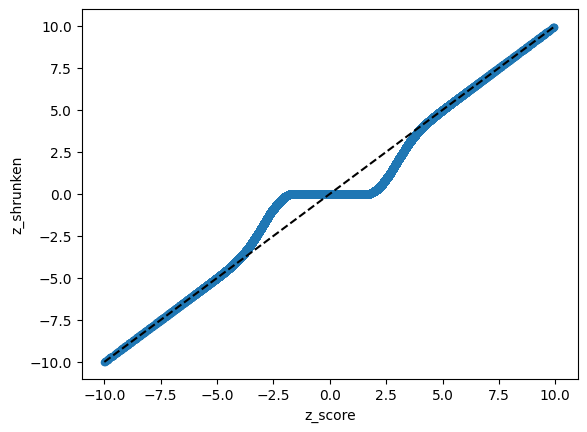

In [6]:
Z_BOUND = 10

(
    derived_summaries.query(f"abs(z_score) < {Z_BOUND}")
    .plot(x = "z_score", y = "z_shrunken", kind = "scatter")
)
plt.plot([-1*Z_BOUND, Z_BOUND], [-1*Z_BOUND, Z_BOUND], color = "black", linestyle = "--")
plt.show()

With this Z-shrunken measure in-hand we can apply a few sanity checks to understand the nature of our signals before moving onto network analysis

### Total patient-level signals and multiomic agreement

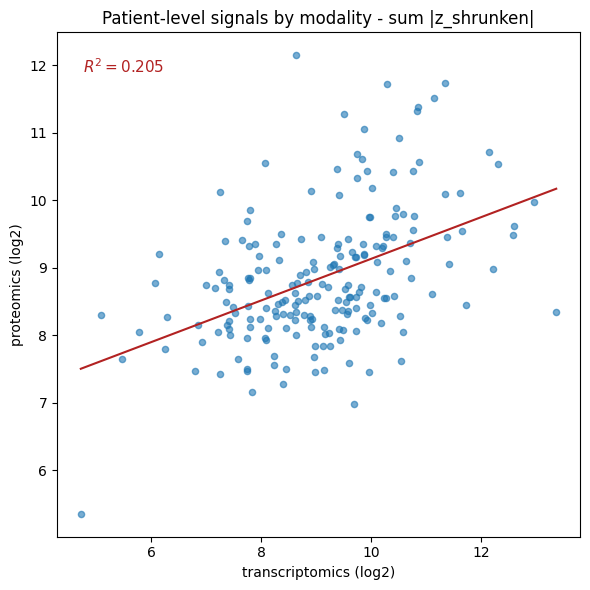

In [7]:
patient_level_summaries = (
    derived_summaries
    .groupby(["modality", "attribute"])["abs_z_shrunken"]
    .sum()
    .reset_index()
    .pivot(index = "attribute", columns = "modality", values = "abs_z_shrunken")
    .dropna()
)

plot_patient_level_signals(patient_level_summaries)


### Look at patient-level scores for MMUT stratified by mutation status

To assess whether the Z-shrunken measure is appropriate, I'll look at the MMUT transcript and gene. The loss of MMUT transcription in most MMUT loss-of-funciton patients is faithfully maintained while many patient's have comparable levels MMUT expression to controls.

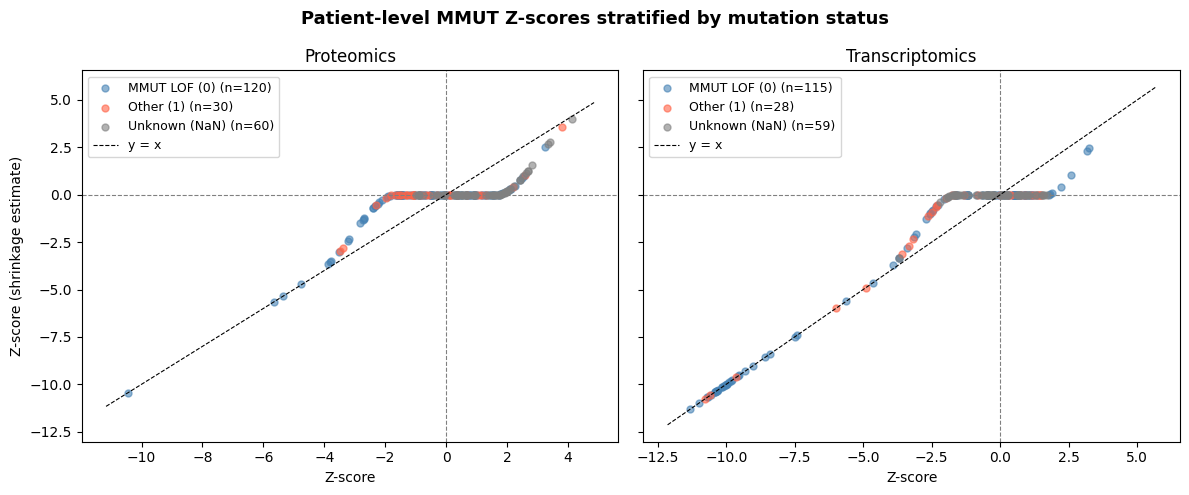

In [8]:
MMUT_IDENTIFIERS = {
    "transcriptomics" : "ENSG00000146085",
    "proteomics" : "P22033"
}

mmut_identifiers_df = pd.DataFrame(MMUT_IDENTIFIERS, index = [0]).melt(var_name = "modality", value_name = "feature_id")
mut_category = get_mut_category(mdata)

# select MMUT protein and stratify by the "mut_status" phenotype (which is 1 for MMUT LOFs)
mmut_stats = derived_summaries.merge(
    mmut_identifiers_df,
    how = "inner",
    on = ["modality", "feature_id"]
).merge(mut_category, left_on = "attribute", right_index = True)

plot_mmut_z_scores(mmut_stats)


## Load NapistuGraph

To find common patterns in patient's level signals, I'll add these signals to a genome-scale directed molecular network [Napistu’s Octopus: An 8-source human consensus pathway model](https://www.shackett.org/octopus_network/) and then apply network propagation ([Network Biology with Napistu, Part 2: Translating Statistical Associations into Biological Mechanisms](https://www.shackett.org/napistu_network_propagation/)) to identify how signal flows upstream in the network, converging on common upstream processes.

In [9]:
# Download raw data from GCS
napistu_artifact_paths = {
    subasset : load_public_napistu_asset(
        NAPISTU_ASSET,
        NAPISTU_DATA_DIR,
        subasset=subasset,
        version=NAPISTU_ASSET_VERSION
    ) for subasset in [GCS_SUBASSET_NAMES.SBML_DFS, GCS_SUBASSET_NAMES.NAPISTU_GRAPH, GCS_SUBASSET_NAMES.SPECIES_IDENTIFIERS]
}

# Load and convert to non-read-only in one step
store = NapistuDataStore.from_huggingface(
    repo_id=HF_EDGE_PREDICTOR_REPO,
    store_dir=Path(NAPISTU_STORE_DIR),
    revision=HF_EDGE_PREDICTOR_REVISION,
    sbml_dfs_path=napistu_artifact_paths[GCS_SUBASSET_NAMES.SBML_DFS],
    napistu_graph_path=napistu_artifact_paths[GCS_SUBASSET_NAMES.NAPISTU_GRAPH],
)


INFO:httpx:HTTP Request: GET https://huggingface.co/api/whoami-v2 "HTTP/1.1 200 OK"
INFO:napistu_torch.ml.hugging_face:✓ HuggingFace authentication verified
INFO:httpx:HTTP Request: GET https://huggingface.co/api/datasets/seanhacks/relation_prediction "HTTP/1.1 200 OK"
INFO:napistu_torch.ml.hugging_face:Loading NapistuDataStore from seanhacks/relation_prediction (revision: main)...
INFO:napistu_torch.ml.hugging_face:Downloading registry.json...
INFO:httpx:HTTP Request: HEAD https://huggingface.co/datasets/seanhacks/relation_prediction/resolve/main/registry.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/seanhacks/relation_prediction/8898e2d98f7c6113e696e944a964b6c766520a10/registry.json "HTTP/1.1 200 OK"
INFO:napistu_torch.ml.hugging_face:✓ Downloaded registry.json to /Users/sean/Desktop/DATA/Forny2023/cache/.store/registry.json
INFO:napistu_torch.ml.hugging_face:Downloading 7 artifact files...
INFO:napistu_torch.ml

## Update NapistuGraph with learned edge weights

The 8-source network I'm using contains regulation from many different resources whose physiological relevance is not calibrated. To use this full network its helpful to have edge weights which can favor certain routes of information transmission based on their mechanistic support. To provide these weights, I'll use learned edge weights from self-supervised edge prediction ([Napistu meets PyTorch Geometric - Predicting Regulatory Interactions with Graph Neural Networks](https://www.shackett.org/napistu_torch/)).

*I actually modified this procedure because the consistently high scores of learned edge weights resulted in oversmoothing of the network, as judged by low enrichment of MMUT in MMUT KO individuals. To deal with this I reverted to the heuristic edge weights conventionally used by Napistu (a fixed edge weight (1) for most sources and for STRING weighting proportional to 1/"overall weight" such that scores fall in approximately a [1, 7] range.)*


In [10]:
# load an edge prediction model which contains a learned edge encoder
evaluation_manager = RemoteEvaluationManager.from_huggingface(
    "seanhacks/edge_prediction_mlp_256e",
    data_store_dir=".store",
)

# load the model and data
model = evaluation_manager.load_model_from_checkpoint()
napistu_data = evaluation_manager.load_napistu_data()

napistu_graph = store.load_napistu_graph()
napistu_data.validate_graph_alignment(napistu_graph)

# pull out learned edge weights (if an edge encoder is present)
if model.task.encoder.edge_weighting_type != "learned_encoder":
    raise ValueError("The provided model does not have a learned edge encoder.")

# Reverse graph and data so edges flow from effects to causes (upstream propagation).
# get_learned_edge_weights uses napistu_data's internal representation, so we must
# reverse napistu_data first to get weights that align with the reversed graph.
napistu_graph.reverse_edges()
napistu_data.reverse_edges(inplace=True)
napistu_data.validate_graph_alignment(napistu_graph)

#edge_encodings = model.get_learned_edge_weights(napistu_data)
# larger scores = better supported; bounded on [0, 1]
#napistu_graph.es["weight"] = edge_encodings.detach().cpu().numpy()

# filter out complexes since these tend to disproprotionately pool signal
napistu_graph.filter_by_species_type(["complex", "drug"], negate = True, inplace=True)


INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/seanhacks/edge_prediction_mlp_256e "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/seanhacks/edge_prediction_mlp_256e/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/seanhacks/edge_prediction_mlp_256e/9ed12a9a7d13370a7664ddff2959b4e99813b110/config.json "HTTP/1.1 200 OK"
INFO:napistu_torch.ml.hugging_face:Config available at: /Users/sean/.cache/huggingface/hub/models--seanhacks--edge_prediction_mlp_256e/snapshots/9ed12a9a7d13370a7664ddff2959b4e99813b110/config.json (using default cache)
INFO:napistu_torch.evaluation.manager:Loading existing data store from .store
INFO:httpx:HTTP Request: HEAD https://huggingface.co/seanhacks/edge_prediction_mlp_256e/resolve/main/model.ckpt "HTTP/1.1 302 Found"
INFO:napistu_torch.ml.hugging_face:Checkpoint available at: /Users/sean/.cache/huggingface/hub/models--seanhacks--edge_pre

## Adding data to the graph

With gene/protein-level summaries and a network graph in-hand, I'll now add each patient's shrunken Z-scores as graph attributes. This involves matches gene identifiers to vertex identifiers (which are included in the "species_identifiers" table). Here, I kept the transcriptome- and proteome-based profiles as separate attributes since as can be seen for MMUT, feature-level agreement is often weak.

In [11]:
PATIENT_MEAURE = "abs_z_shrunken"
species_identifiers = pd.read_csv(napistu_artifact_paths[GCS_SUBASSET_NAMES.SPECIES_IDENTIFIERS], sep="\t")

modality_attr_metadata = list()
for modality in mdata.mod_names:

    ontology = MODALITY_ONTOLOGIES[modality]

    modality_data_working = (
        derived_summaries.query("modality == @modality")
        .pivot(index = "feature_id", columns = "attribute", values = PATIENT_MEAURE)
        .rename_axis(ontology, axis = 0)
    )
    
    # update patient attributes with a modality precursor
    attr_names = modality_data_working.columns
    modality_specific_attr_names = [f"{modality}_{col}" for col in modality_data_working.columns]
    modality_data_working.columns = modality_specific_attr_names

    # map from attributes to a modality indicator used for null distribution construction
    modality_mask_attr = FORNY_DEFS.INDICATOR_STR.format(modality = modality)
    modality_data_working[modality_mask_attr] = 1 # add the modality indicator as a column so its added to the graph
    
    modality_attr_metadata.append(pd.DataFrame({
        "modality_specific_attribute" : modality_specific_attr_names,
        "modality" : modality,
        "attribute" : attr_names,
        "mask" : modality_mask_attr
    }))

    add_feature_abundances_to_graph(
        modality_data_working,
        species_identifiers,
        napistu_graph,
        ontology,
        inplace = True,
        verbose = True
    )

attr_metadata = pd.concat(modality_attr_metadata)


INFO:__main__:Matching features to pathway species
INFO:napistu.matching.species:-1.6% change in feature_ids (8990 vs 9134)
INFO:napistu.matching.species:171 s_id(s) map to more than one feature_id.
INFO:napistu.matching.species:Examples of s_id mapping to multiple feature_ids (showing up to 3):
s_id       s_name       
S00000069  DLD              [76, 1128, 4685, 5662]
S00000085  H2A.J histone        [7493, 7957, 8779]
S00000269  ADH5                        [697, 8193]
Name: feature_id, dtype: object
INFO:napistu.matching.species:274 feature_id(s) map to more than one s_id.
INFO:napistu.matching.species:Examples of feature_id mapping to multiple s_ids (showing up to 3):
feature_id
9      [(S00004018, CYP51A1 gene), (S00033705, CYP51A...
102    [(S00014831, MYLIP gene), (S00024387, NR1H2,3:...
112    [(S00017577, CRY1 gene), (S00037814, p-S90-BMA...
dtype: object
INFO:__main__:Resolving many-to-one (multiple genes → same s_id) and one-to-many (gene → multiple s_ids) degeneracy
INFO:__m

Now, I will propagate each of the 400+ patient-level molecular profiles from genes to their upstream causes using personalized PageRank (PPR). Each's attribute's reset probability is proportional to Z-shrunken so PageRank upweights paths from highly dysregulated nodes. Raw PageRank scores are impacted by both topological biases (high degree nodes score higher) and ascertaintment biases (parts of the network with better coverage in the data will score higher). As discussed in [Network Biology with Napistu, Part 2: Translating Statistical Associations into Biological Mechanisms](https://www.shackett.org/napistu_network_propagation/) I combat topological bias with vertex permutation and ascertainment bias by restricting the nodes selected during vertex permutation.

This works well for a modest number of attributes but profiling hundreds of attributes using this approach with a reasonable number of null samples (which will dictate the resolution of p-values) is too slow. Instead, I assumed that Z-scores are similarly distributed across patients and used a pooled null distribution to compare each patient's vertex-level PPR scores to a shared vertex-level null distribution. This speeds the calculation up considerably but it still takes a few hours so the results here are cached.

In [ ]:
N_NULL_SAMPLES = 1000
OVERWRITE = False

# split up by mask type (here, just transcriptomics vs proteomics)
# and calculate PPR enrichment with a pooled null distribution for each mask
mask_to_measures = attr_metadata.groupby('mask')['modality_specific_attribute'].apply(list).to_dict()

if os.path.isfile(PPR_NULL_TMP_PATH) and not OVERWRITE:
    logger.info(f"Loading PPR nulls from cache at {PPR_NULL_TMP_PATH}")
    ppr_with_nulls = pd.read_parquet(PPR_NULL_TMP_PATH)
else:
    logger.info(f"Calibrating PPR enrichments by permuting vertex attributes among masked vertices")
    ppr_results = list()

    for mask_key, mask_attrs in mask_to_measures.items():
        logger.info(f"Calculating PPR enrichments for {mask_key}")

        modality_ppr_with_nulls = network_propagation_with_null(
            napistu_graph,
            attributes = mask_attrs,
            mask = {attr : mask_key for attr in mask_attrs},
            propagation_method = "personalized_pagerank",
            additional_propagation_args = { "damping": 0.85 },
            null_strategy = "pooled_vertex_permutation",
            n_samples = N_NULL_SAMPLES,
            verbose = True    
        )   

        ppr_results.append(modality_ppr_with_nulls)

    ppr_with_nulls = pd.concat(ppr_results, axis = 1)

    logger.info(f"Saving PPR nulls to cache at {PPR_NULL_TMP_PATH}")
    ppr_with_nulls.to_parquet(PPR_NULL_TMP_PATH)

INFO:__main__:Calibrating PPR enrichments by permuting vertex attributes among masked vertices
INFO:__main__:Calculating PPR enrichments for is_proteomics
INFO:napistu.network.ig_utils:Mask input parsing result:
INFO:napistu.network.ig_utils:  Attribute: 'proteomics_MMA001' -> Mask spec: 'is_proteomics'
INFO:napistu.network.ig_utils:  Attribute: 'proteomics_MMA002' -> Mask spec: 'is_proteomics'
INFO:napistu.network.ig_utils:  Attribute: 'proteomics_MMA003' -> Mask spec: 'is_proteomics'
INFO:napistu.network.ig_utils:  Attribute: 'proteomics_MMA004' -> Mask spec: 'is_proteomics'
INFO:napistu.network.ig_utils:  Attribute: 'proteomics_MMA005' -> Mask spec: 'is_proteomics'
INFO:napistu.network.ig_utils:  Attribute: 'proteomics_MMA006' -> Mask spec: 'is_proteomics'
INFO:napistu.network.ig_utils:  Attribute: 'proteomics_MMA007' -> Mask spec: 'is_proteomics'
INFO:napistu.network.ig_utils:  Attribute: 'proteomics_MMA008' -> Mask spec: 'is_proteomics'
INFO:napistu.network.ig_utils:  Attribute: '

As discussed in the previous PPR post, I can convert the quantiles of observed scores with respect to the null quantiles into two-tailed p-values and I separated the enrichments (more signal relative to the null) from the depletions (less signal relative to the null). This allows me to filter the statistical strong but biological uninteresting depletions and just focus on the statistically enriched subgraphs.

In [ ]:
# name index to vertex_id
tall_ppr_enrichments = (
    melt_propagation_results(ppr_with_nulls, index_name = "vertex", attribute_name = "modality_specific_attribute")
    # drop missing values (due to presence in one but not both modalities)
    .dropna(subset = "quantile")
    # convert to 2-tailed p-values
    .assign(p_value = lambda x: quantile_to_pvalue(x["quantile"], "two-tailed"))
    .assign(is_enriched = lambda x: x["quantile"] > 0.5)
    # correct for 0 p-values by flooring based on the # of null samples
    .assign(p_value = lambda x: floor_pvalue_by_resolution(x["p_value"], N_NULL_SAMPLES))
    .assign(nulls_gt_observed = lambda x: ((1 - x["quantile"])*N_NULL_SAMPLES).fillna(-1).astype(int))
    .merge(attr_metadata[["modality_specific_attribute", "modality", "attribute"]], on = "modality_specific_attribute")
)

fdr_controlled_results = control_fdr(
    tall_ppr_enrichments,
    grouping_vars = ["modality", "is_enriched"],
    require_groups = True,
)


In [ ]:
plot_ppr_enrichment_histograms(fdr_controlled_results)

In [ ]:
personalized_subgraphs = (
    fdr_controlled_results
    .query("is_enriched")
    .query("q_value < 0.01")
    # filter to observed values which are over a tiny threshold to avoid weird issues when ranking floating point error
    .query("observed > 1e-10")
    .query("log2_enrichment > 0.1")
)

vertex_metadata = (
    napistu_graph.get_vertex_dataframe()[["name", "node_name", "species_type", "s_id"]]
    .rename({"name" : "vertex", "node_name" : "vertex_name"}, axis = 1)
)

vertex_protein_metadata = vertex_metadata.query("species_type == 'protein'")

## Clustering personalized subgraphs to separate primary pathology from adaptive pathophysiology



In [ ]:
MARKOV_TIME = 0.9 # 0.85

personalized_subgraph_clusters = dict()
for a_modality_specific_attribute in attr_metadata["modality_specific_attribute"]:
    attribute_enriched_subgraph = napistu_graph.induced_subgraph(personalized_subgraphs.query("modality_specific_attribute == @a_modality_specific_attribute")["vertex"])
    attribute_enriched_subgraph.remove_isolated_vertices(node_types = "species")

    personalized_subgraph_clusters[a_modality_specific_attribute] = run_infomap(
        attribute_enriched_subgraph,
        markov_time = MARKOV_TIME,
        use_subprocess=True
    )

personalized_subgraphs_w_clusters = personalized_subgraphs.merge(
    pd.concat(personalized_subgraph_clusters).rename_axis(["modality_specific_attribute", "vertex"]).reset_index(),
    on = ["modality_specific_attribute", "vertex"]
)


To assess how well the clustering worked, I'll re the size of the largest cluster to the second largest. This provides a simple view into the coarseness of the clustering. Smaller values of *markov time* in `InfoMap` result in shorter walks during the clustering process and finer-grain clusters. While, longer markov times tend to homogenize communities resulting in large clusters.

In [ ]:
def summarize_cluster_sizes(
    personalized_subgraphs_w_clusters: pd.DataFrame,
    attribute_col: str = "modality_specific_attribute",
    module_col: str = "module_id"
) -> pd.DataFrame:
    """
    For each attribute, count vertices per module and return the top 3 largest.

    Parameters
    ----------
    personalized_subgraphs_w_clusters : pd.DataFrame
        Output of merging PPR summaries with module assignments, with one row
        per vertex per attribute.
    attribute_col : str
        Column identifying the attribute (e.g. modality_specific_attribute).
    module_col : str
        Column containing module assignments.

    Returns
    -------
    pd.DataFrame
        Long DataFrame with columns [attribute_col, 'rank', 'module_id', 'n_vertices']
        where rank is 1 (largest), 2, or 3.
    """
    rows = []
    for attr, group in personalized_subgraphs_w_clusters.groupby(attribute_col):
        counts = (
            group
            .groupby(module_col)
            .size()
            .sort_values(ascending=False)
            .head(3)
            .reset_index(name="n_vertices")
        )
        counts.insert(0, attribute_col, attr)
        counts.insert(1, "rank", range(1, len(counts) + 1))
        rows.append(counts)

    return pd.concat(rows, ignore_index=True)

def plot_top2_cluster_sizes(
    cluster_summary: pd.DataFrame,
    attribute_col: str = "modality_specific_attribute",
    modality_col: str = "modality"
) -> None:
    """
    Scatter plot of largest vs second-largest cluster size per attribute.

    Parameters
    ----------
    cluster_summary : pd.DataFrame
        Output of summarize_cluster_sizes, joined with modality if available.
    attribute_col : str
        Column identifying the attribute.
    modality_col : str
        Column for coloring points. If not present, all points same color.
    """
    import matplotlib.pyplot as plt

    pivot = (
        cluster_summary[cluster_summary["rank"].isin([1, 2])]
        .pivot(index=attribute_col, columns="rank", values="n_vertices")
        .rename(columns={1: "largest", 2: "second_largest"})
        .fillna(0)
    )

    # Join modality for coloring if available
    if modality_col in cluster_summary.columns:
        modality_map = (
            cluster_summary[[attribute_col, modality_col]]
            .drop_duplicates()
            .set_index(attribute_col)
        )
        pivot = pivot.join(modality_map)
        modalities = pivot[modality_col].unique()
        colors = dict(zip(modalities, plt.cm.tab10.colors[:len(modalities)]))
    else:
        pivot[modality_col] = "all"
        colors = {"all": "#2166ac"}

    fig, ax = plt.subplots(figsize=(6, 6))

    for modality, group in pivot.groupby(modality_col):
        ax.scatter(
            group["largest"],
            group["second_largest"],
            label=modality,
            color=colors[modality],
            alpha=0.6,
            s=30,
        )

    # y=x reference line
    max_val = pivot[["largest", "second_largest"]].max().max()
    ax.plot([0, max_val], [0, max_val], "k--", linewidth=0.8, alpha=0.4)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Largest cluster (n vertices, log scale)")
    ax.set_ylabel("2nd largest cluster (n vertices, log scale)")
    ax.set_title("Largest vs 2nd largest cluster size per attribute")
    ax.legend(title="Modality")

    plt.tight_layout()
    plt.show()


# Usage
cluster_summary = summarize_cluster_sizes(personalized_subgraphs_w_clusters)
plot_top2_cluster_sizes(cluster_summary)

## Interpreting clusters with gene overexpression analysis

I used gene overexpression analysis to assess whether certain clusters capture promiscuous biology which is likely a homeostatic response to the underlying metabolic defect leading to MMA.

The implementation for this is pretty similar to the `gseapy` where a set of significant vertices is compared to a set of related genes and enrichment is assessed using a Fisher Exact test. The main difference is the Napistu implementation vectorized over genesets and uses a normal approximation. This was needed to efficiently run edgelist GSEA but I'll use the same tooling here since the workflow efficiently maps gene-centric changes on vertices and reorganizes geneset gmts around a set of vertices to assess enrichment.

In [ ]:
from itertools import chain

from napistu.genomics.gsea import GenesetCollection, vertex_ora
from napistu.constants import SBML_DFS

def get_covered_sids(modality):
    col = FORNY_DEFS.INDICATOR_STR.format(modality=modality)
    return (
        napistu_graph.get_vertex_dataframe()[[SBML_DFS.S_ID, col]]
        .dropna(subset=[col])
        [SBML_DFS.S_ID]
        .unique()
    )


gc = GenesetCollection("Homo sapiens")
gc.add_gmts("bp_kegg_hallmarks")

# convert from geneset -> Entrez to geneset -> sids
gmt_sids = gc.get_gmt_w_napistu_ids(species_identifiers)

# define the sids which are in 1+ genesets (since these define the background for enrichment analysis)
sids_w_gmt =  set(chain.from_iterable(gmt_sids.values()))

sid_coverage_by_modality = {m: get_covered_sids(m) for m in mdata.mod_names}

sid_coverage_df = pd.concat([
    pd.DataFrame({"modality": modality, "s_id": sids})
    for modality, sids in sid_coverage_by_modality.items()
], ignore_index=True)


In [ ]:
MIN_CLUSTER_SIZE = 20

personalized_subgraph_proteins = (
    personalized_subgraphs_w_clusters
    .merge(vertex_protein_metadata, on = "vertex", how = "inner")
)

# count the number of MMUT vertices (the protein & its complexes) in each module
mmut_vertices = species_identifiers.query("identifier in @mmut_identifiers_df.feature_id").merge(vertex_metadata[["s_id", "vertex"]], on = "s_id", how = "inner")["vertex"].unique()
mmut_vertices_in_module = personalized_subgraphs_w_clusters.query("vertex in @mmut_vertices").value_counts(["modality_specific_attribute", "module_id"]).rename("mmut_vertices_in_module")

module_summaries = pd.concat(
    [
        personalized_subgraphs_w_clusters.value_counts(["modality_specific_attribute", "module_id"]).rename("total_vertices"),
        personalized_subgraph_proteins.value_counts(["modality_specific_attribute", "module_id"]).rename("protein_vertices"),
        personalized_subgraph_proteins.merge(sid_coverage_df, on = ["modality", "s_id"], how = "inner").value_counts(["modality_specific_attribute", "module_id"]).rename("proteins_with_a_geneset"),
        mmut_vertices_in_module
    ],
    axis = 1
).fillna(0).astype(int)

all_enrichments = list()
for modality in mdata.mod_names:

    covered_sids = sid_coverage_by_modality[modality]
    # geneset using the Napistu vocabulary
    gmt_sids = gc.get_gmt_w_napistu_ids(species_identifiers.query("s_id in @covered_sids"))
    sids_w_gmt = set(chain.from_iterable(gmt_sids.values()))
    
    modality_subgraphs = (
        personalized_subgraph_proteins
        .query("modality == @modality")
        .query("s_id in @covered_sids")
    )

    results = (
        modality_subgraphs
        # filter to just subgraphs with at least 50 proteins
        .merge(
            module_summaries.query("proteins_with_a_geneset >= @MIN_CLUSTER_SIZE").index.to_frame(index=False), 
            on=["modality_specific_attribute", "module_id"], 
            how="inner"
        )
        .groupby(["modality_specific_attribute", "module_id"])
        .apply(
            lambda group: vertex_ora(
                gene_list=group["s_id"].tolist(),
                genesets=gmt_sids,
                universe=sids_w_gmt
            ),
            include_groups=False
        )
    )

    all_enrichments.append(results)
all_enrichments = pd.concat(all_enrichments)

In [ ]:
PROMISCUOUS_GENSETSETS = {
    "cytoskeleton": [
        "c5.go.bp_GOBP_ACTIN_FILAMENT_BASED_PROCESS",
        "c5.go.bp_GOBP_CELL_ADHESION",
        "c5.go.bp_GOBP_CELL_MOTILITY",
        "c5.go.bp_GOBP_CYTOSKELETON_ORGANIZATION",
        "c5.go.bp_GOBP_LOCOMOTION"
        ],
    "stress" : [
        "c5.go.bp_GOBP_DNA_DAMAGE_RESPONSE",
        "c5.go.bp_GOBP_DNA_REPAIR",
        "c5.go.bp_GOBP_VESICLE_MEDIATED_TRANSPORT"
    ]
}

promiscuity_df = pd.DataFrame([
    {"promiscuity_category": category, "term": term}
    for category, terms in PROMISCUOUS_GENSETSETS.items()
    for term in terms
])

promiscuous_enrichments = (
    all_enrichments.reset_index()
    .query("q_value < 0.05")
    .merge(promiscuity_df, on="term", how="inner")
    .groupby(["modality_specific_attribute", "module_id", "promiscuity_category"])
    .size()
    .gt(0)
    .unstack("promiscuity_category")
    .fillna(False)
)

In [ ]:
# add top GO enrichments to each category
modules_w_enriched_terms = (
    all_enrichments
    .query("q_value < 0.05")
    .groupby(["modality_specific_attribute", "module_id"])["term"]
    .apply(lambda x: ", ".join(x))
    .rename("enriched_terms")
)

# add top vertices by log2 enrichment of observed PPR scores compared to nulls in each module
module_top_ppr_enriched_vertices = (
    personalized_subgraphs_w_clusters
    .sort_values(["log2_enrichment"], ascending = False)
    .groupby(["modality_specific_attribute", "module_id"])
    .head(5)
    .merge(vertex_metadata, on = "vertex", how = "inner")
    .groupby(["modality_specific_attribute", "module_id"])["vertex_name"]
    .apply(lambda x: ", ".join(x))
)

full_module_summaries = (
    module_summaries
    # add top enriched terms
    .join(modules_w_enriched_terms)
    # add top vertices by PPR enrichment
    .join(module_top_ppr_enriched_vertices)
    # add flags for promiscuous enrichments
    .join(promiscuous_enrichments).fillna(
        {col: False for col in promiscuous_enrichments.columns}
    )
)

with pd.option_context('display.max_rows', 5, 'display.min_rows', 5, 'display.max_columns', None):
    display(full_module_summaries.sort_values("proteins_with_a_geneset", ascending=False).head(5))

## Summarize strongest root vertices for each patient, modality, and cluster

Now, we can look at possible drivers for individual patients. Starting off, I'll add the rank of each vertex's PPR enrichment above its null both across all of a patients significantly enriched vertices and within vertex's *InfoMap* module.

Most vertices with strong signal are related to coagulation and stress, features which are clear components of MMA.

In [ ]:
# ranks excluding promiscuous modules
promiscuous_modules = promiscuous_enrichments[
    promiscuous_enrichments.any(axis=1)
].index

personalized_ranks_pruned = (
    personalized_subgraphs_w_clusters[
        ~personalized_subgraphs_w_clusters
        .set_index(["modality_specific_attribute", "module_id"])
        .index.isin(promiscuous_modules)
    ]
    .sort_values("log2_enrichment", ascending=False)
    .assign(
        attribute_rank_pruned=lambda df: df.groupby("modality_specific_attribute")[
            "log2_enrichment"
        ].rank(ascending=False, method="first"),
    )
    [["modality_specific_attribute", "vertex", "attribute_rank_pruned"]]
    .set_index(["modality_specific_attribute", "vertex"])
)


# add attribute-level ranks and modality x attribute-level ranks
personalized_ranks = (
    personalized_subgraphs_w_clusters.sort_values("log2_enrichment", ascending=False)
    .assign(
        attribute_rank=lambda df: df.groupby("modality_specific_attribute")[
            "log2_enrichment"
        ].rank(ascending=False, method="first"),
        attribute_module_rank=lambda df: df.groupby(
            ["modality_specific_attribute", "module_id"]
        )["log2_enrichment"].rank(ascending=False, method="first"),
    )
    .join(
        personalized_ranks_pruned,
        on=["modality_specific_attribute", "vertex"]
    )
)


In [ ]:
# examples - top enriched vertices by attribute
personalized_ranks.groupby("modality_specific_attribute").head(1).merge(vertex_metadata, on = "vertex", how = "inner")

### Assessing recovery of MMUT in individuals with MMUT mutations

In [ ]:
mmut_vertices = species_identifiers.query("identifier in @mmut_identifiers_df.feature_id").merge(vertex_metadata[["s_id", "vertex"]], on = "s_id", how = "inner")["vertex"].unique()

attr_enriched_mmut_vertices = (
    personalized_ranks
    .query("vertex in @mmut_vertices")
    .merge(full_module_summaries, left_on = ["modality_specific_attribute", "module_id"], right_index = True, how = "left")
    .merge(mut_category, left_on = "attribute", right_index = True, how = "left")
)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# map mut_category to labeled values before plotting
category_map = {0: "MMUT LOF (0)", 1: "Other (1)"}
palette = {"MMUT LOF (0)": "#6baed6", "Other (1)": "#f4845f", "Unknown (NaN)": "#969696"}

plot_df = attr_enriched_mmut_vertices.copy()
plot_df["mut_category"] = (
    plot_df["mut_category"]
    .map(category_map)
    .fillna("Unknown (NaN)")
)

modalities = plot_df["modality"].unique()

fig, axes = plt.subplots(
    1, len(modalities),
    figsize=(6 * len(modalities), 4),
    sharey=True,
    sharex=True
)

for ax, modality in zip(axes, modalities):
    sns.histplot(
        data=plot_df[plot_df["modality"] == modality],
        x="log2_enrichment",
        hue="mut_category",
        hue_order=["MMUT LOF (0)", "Other (1)", "Unknown (NaN)"],
        palette=palette,
        multiple="stack",
        ax=ax,
        bins = 30
    )
    ax.set_title(modality)
    ax.set_xlabel("log2 enrichment")

fig.suptitle(
    "Enrichment of MMUT vertices above background stratified by MMUT mutation status",
    y=1.02
)

plt.tight_layout()
plt.show()

MMUT vertices are reasonably enriched at the vertex level but when compared to other vertices, MMUT's signals are more modest. This is likely because, while MMUT's specific transcritomics and proteomic signals are particularly strong, "network effects" can concentrate small, but consistent signals onto a common focal vertex. This extensuates effects related to stress and cytoskeleton reorganization which are common pleitropic hubs in disease and also lays focus on coagulation. 

These are real effects but they do partially obscure the MMUT signal if we were going in with no prior knowledge. To separate these adapative homeostatic responses from the primary metabolic effects I clustered the graphs and labelled them as containing stress- or cytoskeleton-related gene sets but often MMUT is in one of these clusters and even when it isn't, removing these promiscuous pathways doesn't radically shift MMUT's rankings.

In [ ]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(attr_enriched_mmut_vertices.sort_values(["mut_category", "modality", "log2_enrichment"], ascending=False))
